In [2]:
import Pkg
Pkg.activate(".")
Pkg.add(["Plots","DifferentialEquations","OrdinaryDiffEq","Logging"]) # Caution takes some time to run the first time 
Pkg.instantiate() 

  Activating project at `~/Documents/MacbookPro/PHYS 4480-7680 Computational Physics/lectures 2026`
     Project No packages added to or removed from `~/Documents/MacbookPro/PHYS 4480-7680 Computational Physics/lectures 2026/Project.toml`
    Manifest No packages added to or removed from `~/Documents/MacbookPro/PHYS 4480-7680 Computational Physics/lectures 2026/Manifest.toml`


In [3]:
using DifferentialEquations,Plots

In [4]:
function plot_xt(trajectory,initialT,finalT,dT;opts...)
    xt=[(t,trajectory(t)[1]) for t in initialT:dT:finalT]
    plot(xt;opts...)
end

function plot_xt!(trajectory,initialT,finalT,dT;opts...)
    xt=[(t,trajectory(t)[1]) for t in initialT:dT:finalT]
    plot!(xt;opts...)
end

function plot_xv(trajectory,initialT,finalT,dT;opts...)
    xv=[Tuple(trajectory(t)) for t in initialT:dT:finalT]
    plot(xv;opts...)
end

function plot_xv!(trajectory,initialT,finalT,dT;opts...)
    xv=[Tuple(trajectory(t)) for t in initialT:dT:finalT]
    plot!(xv;opts...)
end

plot_xv! (generic function with 1 method)

# Closures

One thing that always comes up in scientific programming is that one needs to somehow pass parameters to a function.  As an example, suppose we are simulating the Duffing Oscillator:

\begin{align}
\frac{dx}{dt}&=v\\
\frac{dv}{dt}&=-2\gamma v-\alpha x-\beta x^3 +F \cos(\omega t).
\end{align}

We have parameters: $\gamma$, $F$, $\omega$, $\alpha$, and $\beta$

The ODE solver software is called as

    prob=ODEProblem(dxdt,initialx,tspan)
    solve(prob)

Here `dxdt(x,p,t)` is a function of the vector of dynamical variables `x`, an unused argument `p`, and time `t`.

In [5]:
function duffing(initialxv,T,α,β,γ,F,ω)
    function dxvdt(xv,p,t)
        x,v = xv # unpack argument
        return[v,-2*γ*v-α*x-β*x^3+F*cos(ω*t)]
    end
    tspan=[0., T]
    prob=ODEProblem(dxvdt,initialxv,tspan)
    solve(prob)
end
duffing(initialxv,T;α,β,γ,F,ω)=duffing(initialxv,T,α,β,γ,F,ω)
duffing(;initialxv,T,α,β,γ,F,ω)=duffing(initialxv,T,α,β,γ,F,ω)

duffing (generic function with 3 methods)

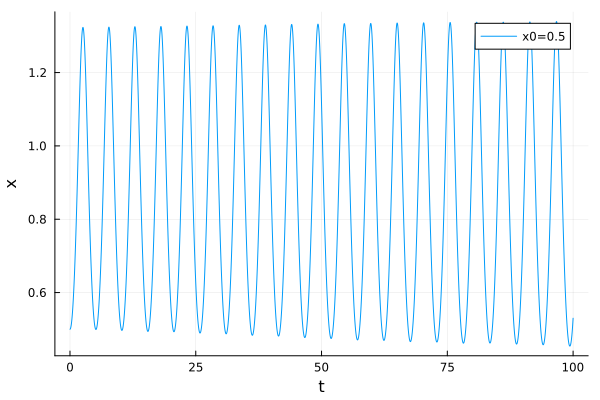

In [6]:
params=(α=-1,β=1,γ=0,F=0,ω=1)
d1=duffing([0.5,0],100;params...);
plot_xt(d1,0,100,0.01;xlabel="t",ylabel="x",label="x0=0.5")

There is a somewhat more sophisticated version of this, where we use a function-like object

In [7]:
mutable struct duffingdxvdt
    γ
    α
    β
    F
    ω
end

duffingdxvdt(;γ,α,β,F,ω)=duffingdxvdt(γ,α,β,F,ω)

function (f::duffingdxvdt)(xv,p,t)
    x,v = xv
    γ=f.γ
    α=f.α
    β=f.β
    F=f.F
    ω=f.ω
    return[v,-2*γ*v-α*x-β*x^3+F*cos(ω*t)]
end

In [8]:
dxvdt1=duffingdxvdt(;params...)

duffingdxvdt(0, -1, 1, 0, 1)

In [11]:
dxvdt1([2,0],nothing,5)

2-element Vector{Float64}:
  0.0
 -6.0

In [28]:
function duffing2(initialxv,T,α,β,γ,F,ω)
    dxvdt=duffingdxvdt(;α,β,γ,F,ω) #order doesn't matter with the semicolon
    # short for 
    #  dxvdt=duffingdxvdt(;α=α,β=β,γ=γ,F=F,ω=ω)
    tspan=[0., T]
    prob=ODEProblem(dxvdt,initialxv,tspan)
    solve(prob)
end

duffing2(initialxv,T;α,β,γ,F,ω)=duffing2(initialxv,T,α,β,γ,F,ω)
duffing2(;initialxv,T,α,β,γ,F,ω)=duffing2(initialxv,T,α,β,γ,F,ω)

duffing2 (generic function with 3 methods)

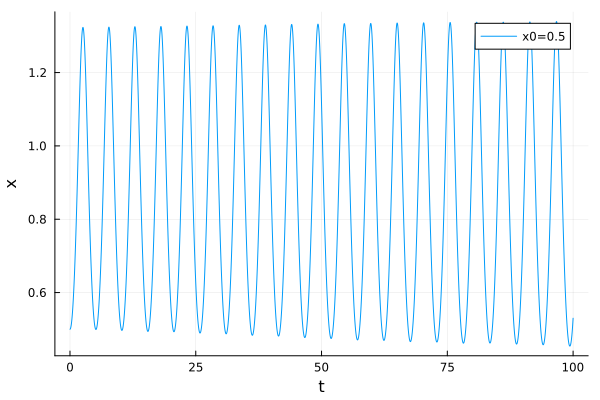

In [29]:
d2=duffing2([0.5,0],100;params...);
plot_xt(d2,0,100,0.01;xlabel="t",ylabel="x",label="x0=0.5")

There is another great way to pass arguments, and that is using the `p` in the `dxdt` function.

In [22]:
function duffdxvdt(xv,p,t)
    x,v = xv
    γ=p.γ
    α=p.α
    β=p.β
    F=p.F
    ω=p.ω
    return[v,-2*γ*v-α*x-β*x^3+F*cos(ω*t)]
end

duffdxvdt (generic function with 1 method)

In [23]:
duffdxvdt([2,0],params,0)

2-element Vector{Float64}:
  0.0
 -6.0

In [30]:
function duffing3(initialxv,T,α,β,γ,F,ω)
    p=(;α,β,γ,F,ω)
    tspan=[0., T]
    prob=ODEProblem(duffdxvdt,initialxv,tspan,p)
    solve(prob)
end
duffing3(initialxv,T;α,β,γ,F,ω)=duffing(initialxv,T,α,β,γ,F,ω)
duffing3(;initialxv,T,α,β,γ,F,ω)=duffing(initialxv,T,α,β,γ,F,ω)

duffing3 (generic function with 3 methods)

In [24]:
function bundle(;a,b,c)
    return(;a,b,c) # create a named tuple
end

bundle (generic function with 1 method)

In [26]:
b1=bundle(;a=5,b=4,c=3)

(a = 5, b = 4, c = 3)

In [27]:
b1.a

5

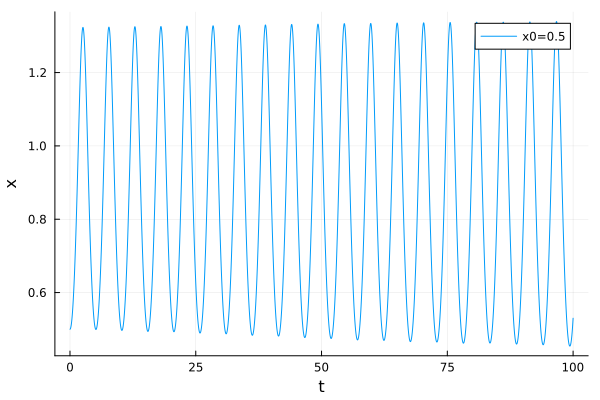

In [31]:
d3=duffing3([0.5,0],100;params...);
plot_xt(d3,0,100,0.01;xlabel="t",ylabel="x",label="x0=0.5")